Columns:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

First 5 Rows:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Dataset Shape:
(5169, 3)

Label Counts:
label
ham     4516
spam     653
Name: count, dtype: int64


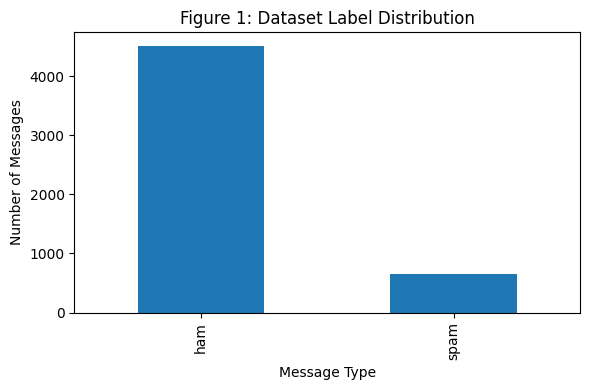


MODEL PERFORMANCE
Accuracy : 0.9710
Precision: 0.9903
Recall   : 0.7786
F1-Score : 0.8718

Classification Report:

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.99      0.78      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



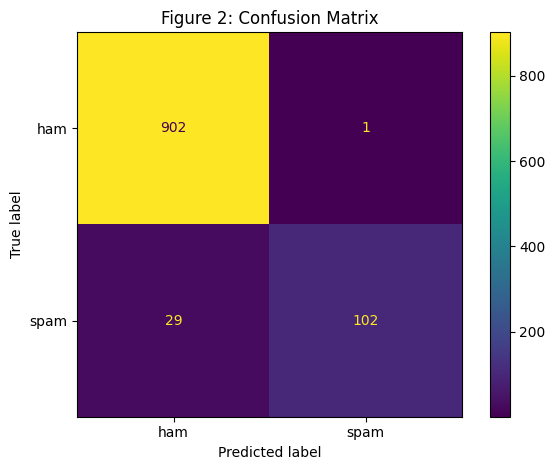


Results Table:
      Metric     Value
0   Accuracy  0.970986
1  Precision  0.990291
2     Recall  0.778626
3   F1-Score  0.871795

All steps completed successfully.


In [10]:
# ================================
# IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ================================
# LOAD DATASET
# ================================

DATA_PATH = Path("../data/SMSSpamCollection.csv") if Path("../data/SMSSpamCollection.csv").exists() else Path("data/SMSSpamCollection.csv")
df = pd.read_csv(DATA_PATH, encoding="latin-1")

# ================================
# CHECK COLUMN NAMES
# ================================

print("Columns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# ================================
# FIX COLUMN NAMES
# ================================

# If dataset columns are v1 and v2
if "v1" in df.columns and "v2" in df.columns:
    df = df.rename(columns={"v1": "label", "v2": "message"})

# Keep only required columns
df = df[["label", "message"]]

# ================================
# CLEAN DATA
# ================================

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Convert labels to numbers
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

# Remove rows with invalid labels
df = df.dropna(subset=["label_num"])

# ================================
# DATASET INFORMATION
# ================================

print("\nDataset Shape:")
print(df.shape)

print("\nLabel Counts:")
print(df["label"].value_counts())

# ================================
# FIGURE 1: LABEL DISTRIBUTION
# ================================

plt.figure(figsize=(6,4))

df["label"].value_counts().plot(kind="bar")

plt.title("Figure 1: Dataset Label Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()

OUTPUT_FIGURES_DIR = Path("../outputs/figures") if Path("../outputs").exists() else Path("outputs/figures")
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_FIGURES_DIR / "figure1_label_distribution.png", dpi=300)

plt.show()

# ================================
# SPLIT DATA
# ================================

X = df["message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# TF-IDF FEATURE EXTRACTION
# ================================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ================================
# TRAIN NAIVE BAYES MODEL
# ================================

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

# ================================
# PREDICTIONS
# ================================

y_pred = model.predict(X_test_tfidf)

# ================================
# EVALUATION
# ================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["ham", "spam"]
))

# ================================
# CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()

plt.title("Figure 2: Confusion Matrix")

plt.tight_layout()

plt.savefig(OUTPUT_FIGURES_DIR / "figure2_confusion_matrix.png", dpi=300)

plt.show()

# ================================
# SAVE RESULTS TABLE
# ================================

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

print("\nResults Table:")
print(results)

OUTPUT_METRICS_DIR = Path("../outputs/metrics") if Path("../outputs").exists() else Path("outputs/metrics")
OUTPUT_METRICS_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(OUTPUT_METRICS_DIR / "tfidf_naive_bayes_results.csv", index=False)

print("\nAll steps completed successfully.")